# Sales Forecasting for a Retail Store

Sales Forecast - MSE: 2969740564.052113
Sales Forecast - R-squared: -0.00249965680379316


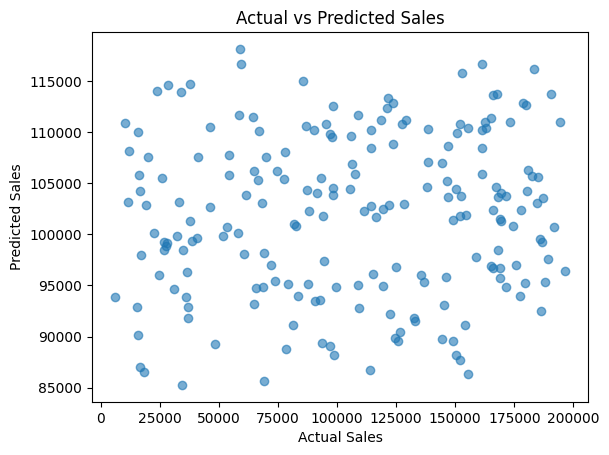

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Load dataset
file_path = "retail_sales_dataset.csv"
data_sales = pd.read_csv(file_path)

# Handle missing values (if any)
data_sales.dropna(inplace=True)

# Identify categorical column(s)
categorical_cols = ['season']

# Apply One-Hot Encoding
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(data_sales[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Merge encoded features with original dataset and drop categorical column
data_sales = data_sales.drop(columns=categorical_cols).reset_index(drop=True)
data_sales = pd.concat([data_sales, encoded_df], axis=1)

# Define features and target variable
X_sales = data_sales.drop(columns=['sales'])  # All columns except 'sales'
y_sales = data_sales['sales']

# Train-test split
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(X_sales, y_sales, test_size=0.2, random_state=42)

# Train the model
model_sales = LinearRegression()
model_sales.fit(X_train_sales, y_train_sales)

# Predictions
y_pred_sales = model_sales.predict(X_test_sales)

# Evaluation
mse_sales = mean_squared_error(y_test_sales, y_pred_sales)
r2_sales = r2_score(y_test_sales, y_pred_sales)

print(f"Sales Forecast - MSE: {mse_sales}")
print(f"Sales Forecast - R-squared: {r2_sales}")

# Visualization
plt.scatter(y_test_sales, y_pred_sales, alpha=0.6)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()
